# BIST Hisseleri ve TCMB Döviz Kuru Verileriyle Risk-Getiri Analizi

## 1. Proje Tanımı

Bu proje, seçilmiş BIST hisseleri ile TCMB USD/TRY döviz kuru verilerini kullanarak risk-getiri ilişkisini inceleyen bir veri bilimi çalışmasıdır.

Notebook içinde veri yükleme, veri temizleme, veri birleştirme, günlük getiri hesaplama, keşifsel veri analizi, görselleştirme, araştırma sorularının yanıtlanması ve basit doğrusal regresyon modelleme adımları uygulanmıştır.

Temel amaç, seçilen hisselerin günlük getiri ve volatilite davranışlarını incelemek, hisse getirileri ile döviz kuru getirileri arasındaki ilişkiyi değerlendirmek ve temel modelleme sürecini sade bir örnekle göstermektir.

Bu çalışma eğitim amaçlıdır ve yatırım tavsiyesi değildir.

## 2. Veri Kaynakları ve Kullanılan Finansal Varlıklar

BIST hisse fiyat verileri Yahoo Finance üzerinden `yfinance` kütüphanesi ile alınmıştır.

TCMB USD/TRY döviz kuru verisi TCMB günlük döviz kuru verilerinden elde edilmiş ve `data/raw/tcmb_usdtry.csv` dosyasında saklanmıştır.

Analizde kullanılan BIST hisseleri: `THYAO.IS`, `ASELS.IS`, `GARAN.IS`, `SISE.IS` ve `KCHOL.IS`.

Döviz kuru değişkeni olarak TCMB USD/TRY döviz alış kuru kullanılmış ve temizlenmiş veri setinde `USDTRY_TCMB` adıyla yer almıştır.

## 3. Kütüphanelerin Yüklenmesi

Bu bölümde veri işleme, görselleştirme, veri indirme, dosya yolu yönetimi ve temel modelleme için kullanılan kütüphaneler yüklenir.

`pandas` ve `numpy` veri işleme için, `matplotlib` ve `seaborn` görselleştirme için, `yfinance` BIST verilerini almak için, `pathlib` ise proje dosya yollarını yönetmek için kullanılmıştır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pathlib import Path

## 4. Veri Yükleme

Bu bölümde ham BIST hisse fiyatları ve TCMB USD/TRY döviz kuru verisi projeye yüklenir.

BIST hisse fiyatları Yahoo Finance üzerinden `yfinance` ile alınır ve kapanış fiyatları `data/raw/bist_close_prices_raw.csv` dosyasına kaydedilir.

TCMB USD/TRY verisi yerel CSV dosyası olarak `data/raw/tcmb_usdtry.csv` konumundan okunur. TCMB verisinin resmi TCMB günlük döviz kuru verilerine dayanması hedeflenmiştir.

In [2]:
current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2022-01-01"
END_DATE = "2026-06-30"
BIST_TICKERS = ["THYAO.IS", "ASELS.IS", "GARAN.IS", "SISE.IS", "KCHOL.IS"]

print(f"Proje ana klasörü: {PROJECT_ROOT}")
print(f"Ham veri klasörü: {RAW_DATA_DIR}")

Proje ana klasörü: C:\Users\omer\Documents\bist-risk-return-analysis
Ham veri klasörü: C:\Users\omer\Documents\bist-risk-return-analysis\data\raw


### BIST Hisse Verilerinin Yüklenmesi

Seçilen BIST hisselerinin fiyat verileri Yahoo Finance üzerinden indirilir.

Bu projede ham veri aşamasında yalnızca kapanış fiyatları seçilir ve `data/raw/bist_close_prices_raw.csv` dosyasına kaydedilir.

In [3]:
yfinance_end_date = (pd.to_datetime(END_DATE) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

bist_raw = yf.download(
    tickers=BIST_TICKERS,
    start=START_DATE,
    end=yfinance_end_date,
    auto_adjust=True,
    progress=False
)

if isinstance(bist_raw.columns, pd.MultiIndex):
    if "Close" in bist_raw.columns.get_level_values(0):
        bist_close = bist_raw["Close"].copy()
    elif "Close" in bist_raw.columns.get_level_values(1):
        bist_close = bist_raw.xs("Close", axis=1, level=1).copy()
    else:
        raise ValueError("İndirilen BIST verisinde kapanış fiyatı sütunu bulunamadı.")
else:
    bist_close = bist_raw[["Close"]].copy()

bist_close.index.name = "Date"
bist_close_path = RAW_DATA_DIR / "bist_close_prices_raw.csv"
bist_close.to_csv(bist_close_path)

print(f"BIST kapanış fiyatları kaydedildi: {bist_close_path}")
print(f"BIST veri boyutu: {bist_close.shape}")
bist_close.head()

BIST kapanış fiyatları kaydedildi: C:\Users\omer\Documents\bist-risk-return-analysis\data\raw\bist_close_prices_raw.csv
BIST veri boyutu: (1125, 5)


Ticker,ASELS.IS,GARAN.IS,KCHOL.IS,SISE.IS,THYAO.IS
Date,,,,,
2022-01-03,10.794637,9.243900,25.651907,12.772174,21.335152
2022-01-04,11.141253,9.219702,25.906223,13.140779,22.272959
2022-01-05,11.398741,9.235834,26.635258,13.279007,23.347530
2022-01-06,11.517581,9.260033,27.194752,13.684473,24.285341
2022-01-07,11.616613,9.477820,27.788153,13.693688,24.363491


### TCMB USD/TRY Verisinin Yüklenmesi

TCMB USD/TRY döviz kuru verisi `data/raw/tcmb_usdtry.csv` dosyasından yüklenir.

CSV dosyasında tarih bilgisi ve USD/TRY döviz alış kuru değeri bulunur. Sütun standardizasyonu ve analizde kullanılacak değişken seçimi veri temizleme bölümünde yapılır.

In [4]:
tcmb_path = RAW_DATA_DIR / "tcmb_usdtry.csv"

if tcmb_path.exists():
    tcmb_raw = pd.read_csv(tcmb_path)
    print(f"TCMB USD/TRY ham verisi yüklendi: {tcmb_path}")
    print(f"TCMB veri boyutu: {tcmb_raw.shape}")
else:
    print("TCMB USD/TRY CSV dosyası bulunamadı.")
    print(f"Lütfen dosyayı şu konuma yerleştirin: {tcmb_path}")
    tcmb_raw = pd.DataFrame()

tcmb_raw.head()

TCMB USD/TRY ham verisi yüklendi: C:\Users\omer\Documents\bist-risk-return-analysis\data\raw\tcmb_usdtry.csv
TCMB veri boyutu: (1117, 6)


,date,usdtry_forex_buying,usdtry_forex_selling,usdtry_banknote_buying,usdtry_banknote_selling,source_url
0,2022-01-03,13.4221,13.4463,13.4127,13.4664,https://www.tcmb.gov.tr/kurlar/202201/03012022...
1,2022-01-04,13.1873,13.2110,13.1780,13.2308,https://www.tcmb.gov.tr/kurlar/202201/04012022...
2,2022-01-05,13.3687,13.3928,13.3594,13.4129,https://www.tcmb.gov.tr/kurlar/202201/05012022...
3,2022-01-06,13.6352,13.6598,13.6257,13.6803,https://www.tcmb.gov.tr/kurlar/202201/06012022...
4,2022-01-07,13.7526,13.7774,13.7430,13.7981,https://www.tcmb.gov.tr/kurlar/202201/07012022...


## 5. Veri Temizleme ve Birleştirme

Bu bölümde ham BIST ve TCMB verileri analiz için hazırlanır.

Tarih formatları standartlaştırılır; eksik değerler, veri tipleri ve tekrar eden tarihler kontrol edilir.

TCMB USD/TRY döviz alış kuru, `USDTRY_TCMB` değişkeni olarak kullanılır.

BIST ve TCMB verileri ortak tarihler üzerinden birleştirilerek fiyat düzeyinde temiz bir veri seti oluşturulur.

### BIST Ham Kapanış Fiyatlarının Yüklenmesi

Bu hücre, BIST kapanış fiyatları önceki hücrelerde zaten oluşturulduysa o veriyi kullanır. Eğer veri bellekte yoksa `data/raw/bist_close_prices_raw.csv` dosyasından yüklemeyi dener.

In [5]:
bist_raw_path = RAW_DATA_DIR / "bist_close_prices_raw.csv"

if "bist_close_prices" in globals():
    bist_source = bist_close_prices.copy()
    print("BIST kapanış fiyatları önceki hücrelerdeki bist_close_prices değişkeninden alındı.")
elif "bist_close" in globals():
    bist_source = bist_close.copy()
    print("BIST kapanış fiyatları önceki yfinance hücresindeki bist_close değişkeninden alındı.")
elif bist_raw_path.exists():
    bist_source = pd.read_csv(bist_raw_path)
    print(f"BIST kapanış fiyatları ham CSV dosyasından yüklendi: {bist_raw_path}")
else:
    raise FileNotFoundError(
        "BIST ham kapanış fiyatları bulunamadı. "
        "Önce yfinance veri yükleme hücresini çalıştırın veya "
        "data/raw/bist_close_prices_raw.csv dosyasını oluşturun."
    )

print(f"BIST ham veri boyutu: {bist_source.shape}")
bist_source.head()

BIST kapanış fiyatları önceki yfinance hücresindeki bist_close değişkeninden alındı.
BIST ham veri boyutu: (1125, 5)


Ticker,ASELS.IS,GARAN.IS,KCHOL.IS,SISE.IS,THYAO.IS
Date,,,,,
2022-01-03,10.794637,9.243900,25.651907,12.772174,21.335152
2022-01-04,11.141253,9.219702,25.906223,13.140779,22.272959
2022-01-05,11.398741,9.235834,26.635258,13.279007,23.347530
2022-01-06,11.517581,9.260033,27.194752,13.684473,24.285341
2022-01-07,11.616613,9.477820,27.788153,13.693688,24.363491


### BIST Verisinin Temizlenmesi

Bu bölümde BIST kapanış fiyatlarının tarih alanı standartlaştırılır, seçilen hisse sütunları korunur ve temel kalite kontrolleri yapılır.

Eksik değerler, veri tipleri ve tekrar eden tarihler kontrol edilir.

In [6]:
selected_bist_columns = BIST_TICKERS
bist_clean = bist_source.copy()

if isinstance(bist_clean.columns, pd.MultiIndex):
    if "Close" in bist_clean.columns.get_level_values(0):
        bist_clean = bist_clean["Close"].copy()
    elif "Close" in bist_clean.columns.get_level_values(1):
        bist_clean = bist_clean.xs("Close", axis=1, level=1).copy()
    else:
        raise ValueError("BIST verisinde kapanış fiyatı alanı bulunamadı.")

bist_clean.columns = [str(column).strip() for column in bist_clean.columns]
date_candidates = [
    column for column in bist_clean.columns
    if column.lower() in ["date", "datetime"] or column.lower().startswith("unnamed")
]

if date_candidates:
    bist_clean = bist_clean.rename(columns={date_candidates[0]: "date"})
else:
    bist_clean = bist_clean.reset_index()
    bist_clean = bist_clean.rename(columns={bist_clean.columns[0]: "date"})

bist_clean["date"] = pd.to_datetime(bist_clean["date"], errors="coerce")

if bist_clean["date"].isna().any():
    raise ValueError("BIST tarih alanında dönüştürülemeyen değerler var.")

missing_bist_columns = [column for column in selected_bist_columns if column not in bist_clean.columns]
if missing_bist_columns:
    raise ValueError(f"BIST verisinde beklenen sütunlar eksik: {missing_bist_columns}")

for column in selected_bist_columns:
    bist_clean[column] = pd.to_numeric(bist_clean[column], errors="coerce")

bist_clean = bist_clean[["date"] + selected_bist_columns]
bist_clean = bist_clean.sort_values("date").reset_index(drop=True)

duplicate_bist_dates = bist_clean["date"].duplicated().sum()
print(f"BIST tekrar eden tarih sayısı: {duplicate_bist_dates}")

if duplicate_bist_dates > 0:
    bist_clean = bist_clean.drop_duplicates(subset="date", keep="first").reset_index(drop=True)
    print("BIST verisinde tekrar eden tarihler ilk kayıt korunarak kaldırıldı.")

print(f"BIST temiz veri boyutu: {bist_clean.shape}")
print("BIST eksik değer sayıları:")
print(bist_clean.isna().sum())
print("\nBIST veri tipleri:")
print(bist_clean.dtypes)

bist_clean.head()

BIST tekrar eden tarih sayısı: 0
BIST temiz veri boyutu: (1125, 6)
BIST eksik değer sayıları:
date        0
THYAO.IS    0
ASELS.IS    0
GARAN.IS    0
SISE.IS     0
KCHOL.IS    0
dtype: int64

BIST veri tipleri:
date        datetime64[s]
THYAO.IS          float64
ASELS.IS          float64
GARAN.IS          float64
SISE.IS           float64
KCHOL.IS          float64
dtype: object


,date,THYAO.IS,ASELS.IS,GARAN.IS,SISE.IS,KCHOL.IS
0,2022-01-03,21.335152,10.794637,9.243900,12.772174,25.651907
1,2022-01-04,22.272959,11.141253,9.219702,13.140779,25.906223
2,2022-01-05,23.347530,11.398741,9.235834,13.279007,26.635258
3,2022-01-06,24.285341,11.517581,9.260033,13.684473,27.194752
4,2022-01-07,24.363491,11.616613,9.477820,13.693688,27.788153


### TCMB USD/TRY Verisinin Temizlenmesi

Bu bölümde TCMB ham döviz kuru verisi yüklenir ve analizde yalnızca `date` ile `usdtry_forex_buying` sütunları kullanılır.

`usdtry_forex_buying` sayısal formata çevrilir ve `USDTRY_TCMB` adıyla yeniden adlandırılır.

In [7]:
tcmb_raw_path = RAW_DATA_DIR / "tcmb_usdtry.csv"

if not tcmb_raw_path.exists():
    raise FileNotFoundError(
        "TCMB USD/TRY ham veri dosyası bulunamadı. "
        "Lütfen data/raw/tcmb_usdtry.csv dosyasını ekleyin."
    )

tcmb_source = pd.read_csv(tcmb_raw_path)
tcmb_clean = tcmb_source.copy()

required_tcmb_columns = ["date", "usdtry_forex_buying"]
missing_tcmb_columns = [column for column in required_tcmb_columns if column not in tcmb_clean.columns]
if missing_tcmb_columns:
    raise ValueError(f"TCMB verisinde beklenen sütunlar eksik: {missing_tcmb_columns}")

tcmb_clean["date"] = pd.to_datetime(tcmb_clean["date"], errors="coerce")
tcmb_clean["USDTRY_TCMB"] = pd.to_numeric(tcmb_clean["usdtry_forex_buying"], errors="coerce")
tcmb_clean = tcmb_clean[["date", "USDTRY_TCMB"]]
tcmb_clean = tcmb_clean.sort_values("date").reset_index(drop=True)

if tcmb_clean["date"].isna().any():
    raise ValueError("TCMB tarih alanında dönüştürülemeyen değerler var.")

duplicate_tcmb_dates = tcmb_clean["date"].duplicated().sum()
print(f"TCMB tekrar eden tarih sayısı: {duplicate_tcmb_dates}")

if duplicate_tcmb_dates > 0:
    tcmb_clean = tcmb_clean.drop_duplicates(subset="date", keep="first").reset_index(drop=True)
    print("TCMB verisinde tekrar eden tarihler ilk kayıt korunarak kaldırıldı.")

print(f"TCMB temiz veri boyutu: {tcmb_clean.shape}")
print("TCMB eksik değer sayıları:")
print(tcmb_clean.isna().sum())
print("\nTCMB veri tipleri:")
print(tcmb_clean.dtypes)

tcmb_clean.head()

TCMB tekrar eden tarih sayısı: 0
TCMB temiz veri boyutu: (1117, 2)
TCMB eksik değer sayıları:
date           0
USDTRY_TCMB    0
dtype: int64

TCMB veri tipleri:
date           datetime64[us]
USDTRY_TCMB           float64
dtype: object


,date,USDTRY_TCMB
0,2022-01-03,13.4221
1,2022-01-04,13.1873
2,2022-01-05,13.3687
3,2022-01-06,13.6352
4,2022-01-07,13.7526


### BIST ve TCMB Verilerinin Birleştirilmesi

BIST ve TCMB verileri `date` sütunu üzerinden iç birleşim yöntemiyle birleştirilir.

Bu yöntemle yalnızca iki veri kaynağında da ortak olan işlem günleri analiz veri setine alınır.

In [8]:
price_data = pd.merge(
    bist_clean,
    tcmb_clean,
    on="date",
    how="inner"
)

price_data = price_data.sort_values("date").reset_index(drop=True)

print(f"Birleştirilmiş fiyat veri seti boyutu: {price_data.shape}")
print(f"Başlangıç tarihi: {price_data['date'].min()}")
print(f"Bitiş tarihi: {price_data['date'].max()}")
print("\nBirleştirilmiş veri eksik değer sayıları:")
print(price_data.isna().sum())
print("\nBirleştirilmiş veri tipleri:")
print(price_data.dtypes)

print("\nİlk satırlar:")
display(price_data.head())

print("Son satırlar:")
display(price_data.tail())

print("Sayısal değişkenlerin özet istatistikleri:")
display(price_data.describe())

Birleştirilmiş fiyat veri seti boyutu: (1113, 7)
Başlangıç tarihi: 2022-01-03 00:00:00
Bitiş tarihi: 2026-06-30 00:00:00

Birleştirilmiş veri eksik değer sayıları:
date           0
THYAO.IS       0
ASELS.IS       0
GARAN.IS       0
SISE.IS        0
KCHOL.IS       0
USDTRY_TCMB    0
dtype: int64

Birleştirilmiş veri tipleri:
date           datetime64[s]
THYAO.IS             float64
ASELS.IS             float64
GARAN.IS             float64
SISE.IS              float64
KCHOL.IS             float64
USDTRY_TCMB          float64
dtype: object

İlk satırlar:


,date,THYAO.IS,ASELS.IS,GARAN.IS,SISE.IS,KCHOL.IS,USDTRY_TCMB
0,2022-01-03,21.335152,10.794637,9.243900,12.772174,25.651907,13.4221
1,2022-01-04,22.272959,11.141253,9.219702,13.140779,25.906223,13.1873
2,2022-01-05,23.347530,11.398741,9.235834,13.279007,26.635258,13.3687
3,2022-01-06,24.285341,11.517581,9.260033,13.684473,27.194752,13.6352
4,2022-01-07,24.363491,11.616613,9.477820,13.693688,27.788153,13.7526


Son satırlar:


,date,THYAO.IS,ASELS.IS,GARAN.IS,SISE.IS,KCHOL.IS,USDTRY_TCMB
1108,2026-06-24,324.75,367.5,140.399994,45.099998,193.000000,46.4099
1109,2026-06-25,328.50,373.5,137.600006,44.240002,194.899994,46.4302
1110,2026-06-26,330.75,361.5,138.399994,45.320000,198.199997,46.4482
1111,2026-06-29,329.00,357.5,137.300003,44.939999,195.699997,46.5551
1112,2026-06-30,326.00,345.0,138.000000,44.299999,193.500000,46.5747


Sayısal değişkenlerin özet istatistikleri:


,date,THYAO.IS,ASELS.IS,GARAN.IS,SISE.IS,KCHOL.IS,USDTRY_TCMB
count,1113,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000
mean,2024-03-29 08:58:13,217.003133,95.484853,73.387067,37.486257,125.842025,29.926424
min,2022-01-03 00:00:00,21.335152,9.358653,8.880919,10.818567,25.261959,13.187300
25%,2023-02-15 00:00:00,131.586304,26.273657,22.121298,34.395260,67.180115,18.828200
50%,2024-03-25 00:00:00,267.422058,56.086697,60.899410,39.355553,141.701797,32.100500
75%,2025-05-13 00:00:00,294.500000,135.127838,120.495346,45.409817,171.485809,38.634900
max,2026-06-30 00:00:00,347.750000,434.000000,158.591171,54.067856,242.907516,46.574700
std,NaN,99.493520,104.659798,49.142130,10.363513,59.656404,9.989683


### Temizlenmiş Fiyat Verisinin Kaydedilmesi

Ortak tarihler üzerinden oluşturulan fiyat düzeyindeki veri seti `data/processed/clean_price_data.csv` dosyasına kaydedilir.

Bu dosya günlük getiri hesaplama ve sonraki analizlerde kullanılır.

In [9]:
clean_price_data_path = PROCESSED_DATA_DIR / "clean_price_data.csv"
price_data.to_csv(clean_price_data_path, index=False)

print(f"Temizlenmiş fiyat veri seti kaydedildi: {clean_price_data_path}")

Temizlenmiş fiyat veri seti kaydedildi: C:\Users\omer\Documents\bist-risk-return-analysis\data\processed\clean_price_data.csv


## 6. Günlük Getiri Hesaplama

Bu bölümde fiyat seviyelerinden günlük yüzde getiriler hesaplanır.

Ham fiyatlar farklı ölçeklerde olduğu için varlıkları doğrudan fiyat seviyeleriyle karşılaştırmak yanıltıcı olabilir. Günlük getiriler, hisseleri ve döviz kurunu daha karşılaştırılabilir hale getirir.

Oluşturulan günlük getiri veri seti EDA, araştırma soruları ve basit modelleme bölümlerinde kullanılır.

### Temizlenmiş Fiyat Verisinin Yüklenmesi

Bu hücre, fiyat düzeyindeki temiz veri setini modelleme ve getiri hesaplama süreci için hazırlar.

`price_data` bellekte varsa doğrudan kullanılır; yoksa `data/processed/clean_price_data.csv` dosyasından yüklenir.

In [10]:
clean_price_data_path = PROCESSED_DATA_DIR / "clean_price_data.csv"

if "price_data" in globals() and isinstance(price_data, pd.DataFrame) and not price_data.empty:
    price_source = price_data.copy()
    print("Temizlenmiş fiyat verisi önceki hücrelerdeki price_data değişkeninden alındı.")
elif clean_price_data_path.exists():
    price_source = pd.read_csv(clean_price_data_path)
    print(f"Temizlenmiş fiyat verisi dosyadan yüklendi: {clean_price_data_path}")
else:
    print("Temizlenmiş fiyat veri dosyası bulunamadı.")
    print("Lütfen önce veri temizleme ve birleştirme bölümündeki hücreleri çalıştırın.")
    price_source = pd.DataFrame()

print(f"Fiyat verisi boyutu: {price_source.shape}")
price_source.head()

Temizlenmiş fiyat verisi önceki hücrelerdeki price_data değişkeninden alındı.
Fiyat verisi boyutu: (1113, 7)


,date,THYAO.IS,ASELS.IS,GARAN.IS,SISE.IS,KCHOL.IS,USDTRY_TCMB
0,2022-01-03,21.335152,10.794637,9.243900,12.772174,25.651907,13.4221
1,2022-01-04,22.272959,11.141253,9.219702,13.140779,25.906223,13.1873
2,2022-01-05,23.347530,11.398741,9.235834,13.279007,26.635258,13.3687
3,2022-01-06,24.285341,11.517581,9.260033,13.684473,27.194752,13.6352
4,2022-01-07,24.363491,11.616613,9.477820,13.693688,27.788153,13.7526


### Getiri Hesaplaması İçin Verinin Hazırlanması

Bu bölümde tarih alanı standartlaştırılır, veri tarihe göre sıralanır ve günlük getiri hesaplamasında kullanılacak fiyat sütunları seçilir.

In [11]:
price_columns = ["THYAO.IS", "ASELS.IS", "GARAN.IS", "SISE.IS", "KCHOL.IS", "USDTRY_TCMB"]
required_price_columns = ["date"] + price_columns

if price_source.empty:
    price_for_returns = pd.DataFrame(columns=required_price_columns)
    print("Fiyat verisi boş olduğu için getiri hesaplamasına hazırlık yapılamadı.")
else:
    missing_price_columns = [column for column in required_price_columns if column not in price_source.columns]
    if missing_price_columns:
        raise ValueError(f"Temiz fiyat verisinde beklenen sütunlar eksik: {missing_price_columns}")

    price_for_returns = price_source[required_price_columns].copy()
    price_for_returns["date"] = pd.to_datetime(price_for_returns["date"], errors="coerce")

    if price_for_returns["date"].isna().any():
        raise ValueError("Fiyat verisindeki tarih alanında dönüştürülemeyen değerler var.")

    for column in price_columns:
        price_for_returns[column] = pd.to_numeric(price_for_returns[column], errors="coerce")

    price_for_returns = price_for_returns.sort_values("date").reset_index(drop=True)

print(f"Getiri hesaplamasına hazırlanmış fiyat verisi boyutu: {price_for_returns.shape}")
price_for_returns.head()

Getiri hesaplamasına hazırlanmış fiyat verisi boyutu: (1113, 7)


,date,THYAO.IS,ASELS.IS,GARAN.IS,SISE.IS,KCHOL.IS,USDTRY_TCMB
0,2022-01-03,21.335152,10.794637,9.243900,12.772174,25.651907,13.4221
1,2022-01-04,22.272959,11.141253,9.219702,13.140779,25.906223,13.1873
2,2022-01-05,23.347530,11.398741,9.235834,13.279007,26.635258,13.3687
3,2022-01-06,24.285341,11.517581,9.260033,13.684473,27.194752,13.6352
4,2022-01-07,24.363491,11.616613,9.477820,13.693688,27.788153,13.7526


### Günlük Yüzde Getirilerin Hesaplanması

Bu bölümde BIST hisseleri ve TCMB USD/TRY kuru için günlük yüzde getiriler `pct_change()` ile hesaplanır.

İlk satır, önceki gün bilgisi olmadığı için eksik değer içerir ve veri setinden çıkarılır.

In [12]:
return_column_names = {
    "THYAO.IS": "THYAO_Return",
    "ASELS.IS": "ASELS_Return",
    "GARAN.IS": "GARAN_Return",
    "SISE.IS": "SISE_Return",
    "KCHOL.IS": "KCHOL_Return",
    "USDTRY_TCMB": "USDTRY_Return",
}

if price_for_returns.empty:
    return_data = pd.DataFrame(columns=["date"] + list(return_column_names.values()))
    print("Fiyat verisi boş olduğu için günlük getiri hesaplanmadı.")
else:
    # Ham fiyatlar farklı ölçeklerde olduğu için günlük getiriler varlıkları karşılaştırmayı kolaylaştırır.
    calculated_returns = price_for_returns[price_columns].pct_change()
    calculated_returns = calculated_returns.rename(columns=return_column_names)

    return_data = pd.concat(
        [price_for_returns[["date"]], calculated_returns],
        axis=1
    )
    return_data = return_data.dropna().reset_index(drop=True)

print(f"Günlük getiri veri seti boyutu: {return_data.shape}")
return_data.head()

Günlük getiri veri seti boyutu: (1112, 7)


,date,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
0,2022-01-04,0.043956,0.032110,-0.002618,0.028860,0.009914,-0.017494
1,2022-01-05,0.048246,0.023111,0.001750,0.010519,0.028141,0.013756
2,2022-01-06,0.040167,0.010426,0.002620,0.030534,0.021006,0.019935
3,2022-01-07,0.003218,0.008598,0.023519,0.000673,0.021820,0.008610
4,2022-01-10,0.070569,0.031543,-0.000851,0.002692,-0.004271,-0.002407


### Günlük Getiri Verisi Kontrolleri

Günlük getiri veri seti oluşturulduktan sonra ilk ve son satırlar, veri boyutu, eksik değerler, veri tipleri ve temel özet istatistikler kontrol edilir.

In [13]:
print(f"Günlük getiri veri seti boyutu: {return_data.shape}")

print("İlk satırlar:")
display(return_data.head())

print("Son satırlar:")
display(return_data.tail())

print("Eksik değer sayıları:")
print(return_data.isna().sum())

print("\nVeri tipleri:")
print(return_data.dtypes)

print("\nGünlük getiriler için özet istatistikler:")
display(return_data.describe())

Günlük getiri veri seti boyutu: (1112, 7)
İlk satırlar:


,date,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
0,2022-01-04,0.043956,0.032110,-0.002618,0.028860,0.009914,-0.017494
1,2022-01-05,0.048246,0.023111,0.001750,0.010519,0.028141,0.013756
2,2022-01-06,0.040167,0.010426,0.002620,0.030534,0.021006,0.019935
3,2022-01-07,0.003218,0.008598,0.023519,0.000673,0.021820,0.008610
4,2022-01-10,0.070569,0.031543,-0.000851,0.002692,-0.004271,-0.002407


Son satırlar:


,date,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
1107,2026-06-24,-0.000769,-0.062500,-0.002132,-0.000886,0.007307,0.000375
1108,2026-06-25,0.011547,0.016327,-0.019943,-0.019069,0.009845,0.000437
1109,2026-06-26,0.006849,-0.032129,0.005814,0.024412,0.016932,0.000388
1110,2026-06-29,-0.005291,-0.011065,-0.007948,-0.008385,-0.012614,0.002301
1111,2026-06-30,-0.009119,-0.034965,0.005098,-0.014241,-0.011242,0.000421


Eksik değer sayıları:
date             0
THYAO_Return     0
ASELS_Return     0
GARAN_Return     0
SISE_Return      0
KCHOL_Return     0
USDTRY_Return    0
dtype: int64

Veri tipleri:
date             datetime64[s]
THYAO_Return           float64
ASELS_Return           float64
GARAN_Return           float64
SISE_Return            float64
KCHOL_Return           float64
USDTRY_Return          float64
dtype: object

Günlük getiriler için özet istatistikler:


,date,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
count,1112,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000
mean,2024-03-30 02:35:23,0.002784,0.003564,0.002863,0.001427,0.002133,0.001130
min,2022-01-04 00:00:00,-0.099715,-0.100000,-0.099925,-0.089587,-0.099946,-0.040455
25%,2023-02-15 18:00:00,-0.012741,-0.015488,-0.013654,-0.013699,-0.013632,0.000075
50%,2024-03-25 12:00:00,0.000819,0.001659,0.000696,0.000000,0.001466,0.000503
75%,2025-05-13 06:00:00,0.015722,0.020024,0.017781,0.015001,0.014970,0.001568
max,2026-06-30 00:00:00,0.216522,0.220126,0.177428,0.169222,0.148485,0.072915
std,NaN,0.025846,0.029946,0.029456,0.024964,0.025182,0.004659


### Günlük Getiri Verisinin Kaydedilmesi

Oluşturulan günlük getiri veri seti `data/processed/daily_return_data.csv` dosyasına kaydedilir.

Bu dosya keşifsel veri analizi, görselleştirme, araştırma soruları ve modelleme adımlarında kullanılır.

In [14]:
daily_return_data_path = PROCESSED_DATA_DIR / "daily_return_data.csv"

if return_data.empty:
    print("Günlük getiri veri seti boş olduğu için dosya kaydedilmedi.")
else:
    return_data.to_csv(daily_return_data_path, index=False)
    print(f"Günlük getiri veri seti kaydedildi: {daily_return_data_path}")

Günlük getiri veri seti kaydedildi: C:\Users\omer\Documents\bist-risk-return-analysis\data\processed\daily_return_data.csv


## 7. Keşifsel Veri Analizi ve Görselleştirmeler

Bu bölümde günlük getiri veri seti kullanılarak temel keşifsel veri analizi ve görselleştirmeler yapılır.

Günlük getiriler farklı fiyat ölçeklerini karşılaştırmak için kullanılır. Volatilite, günlük getirilerin standart sapmasıyla temsil edilir. Korelasyon ise varlıkların birlikte hareket edip etmediğini anlamak için kullanılır.

Aykırı değerler finansal verilerde normal olabilir; bu projede aykırı değerler yalnızca incelenir, silinmez.

Bu çalışma eğitim amaçlıdır ve yatırım tavsiyesi değildir. Bu bölümde araştırma soruları henüz yanıtlanmaz ve modelleme yapılmaz.

### EDA İçin Günlük Getiri Verisinin Yüklenmesi

Bu hücre, `return_data` değişkeni bellekte varsa onu kullanır. Eğer bellekte yoksa `data/processed/daily_return_data.csv` dosyasından günlük getiri verisini yüklemeyi dener.

Dosya bulunamazsa önceki notebook hücrelerinin çalıştırılması gerektiğini belirten açık bir Türkçe mesaj gösterilir.

In [15]:
daily_return_data_path = PROCESSED_DATA_DIR / "daily_return_data.csv"
clean_price_data_path = PROCESSED_DATA_DIR / "clean_price_data.csv"

if "return_data" in globals() and isinstance(return_data, pd.DataFrame) and not return_data.empty:
    eda_return_data = return_data.copy()
    print("Günlük getiri verisi bellekteki return_data değişkeninden alındı.")
elif daily_return_data_path.exists():
    eda_return_data = pd.read_csv(daily_return_data_path)
    print(f"Günlük getiri verisi dosyadan yüklendi: {daily_return_data_path}")
else:
    print("Günlük getiri veri dosyası bulunamadı.")
    print("Lütfen önce veri yükleme, temizleme ve günlük getiri hesaplama hücrelerini çalıştırın.")
    eda_return_data = pd.DataFrame()

if "price_data" in globals() and isinstance(price_data, pd.DataFrame) and not price_data.empty:
    eda_price_data = price_data.copy()
    print("Fiyat seviyesi verisi bellekteki price_data değişkeninden alındı.")
elif clean_price_data_path.exists():
    eda_price_data = pd.read_csv(clean_price_data_path)
    print(f"Fiyat seviyesi verisi dosyadan yüklendi: {clean_price_data_path}")
else:
    print("Temizlenmiş fiyat veri dosyası bulunamadı.")
    print("Çizgi grafik için önce veri temizleme ve birleştirme hücreleri çalıştırılmalıdır.")
    eda_price_data = pd.DataFrame()

for dataframe in [eda_return_data, eda_price_data]:
    if not dataframe.empty and "date" in dataframe.columns:
        dataframe["date"] = pd.to_datetime(dataframe["date"], errors="coerce")

return_columns = [
    "THYAO_Return",
    "ASELS_Return",
    "GARAN_Return",
    "SISE_Return",
    "KCHOL_Return",
    "USDTRY_Return",
]

print(f"EDA getiri verisi boyutu: {eda_return_data.shape}")
print(f"EDA fiyat verisi boyutu: {eda_price_data.shape}")

Günlük getiri verisi bellekteki return_data değişkeninden alındı.
Fiyat seviyesi verisi bellekteki price_data değişkeninden alındı.
EDA getiri verisi boyutu: (1112, 7)
EDA fiyat verisi boyutu: (1113, 7)


### Temel Yapı Kontrolü

Bu bölümde günlük getiri veri setinin boyutu, ilk ve son satırları, eksik değerleri ve veri tipleri kontrol edilir.

In [16]:
print(f"Günlük getiri veri seti boyutu: {eda_return_data.shape}")

if eda_return_data.empty:
    print("Günlük getiri veri seti boş olduğu için yapı kontrolü yapılamadı.")
else:
    print("İlk satırlar:")
    display(eda_return_data.head())

    print("Son satırlar:")
    display(eda_return_data.tail())

    print("Eksik değer sayıları:")
    print(eda_return_data.isna().sum())

    print()
    print("Veri tipleri:")
    print(eda_return_data.dtypes)

Günlük getiri veri seti boyutu: (1112, 7)
İlk satırlar:


,date,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
0,2022-01-04,0.043956,0.032110,-0.002618,0.028860,0.009914,-0.017494
1,2022-01-05,0.048246,0.023111,0.001750,0.010519,0.028141,0.013756
2,2022-01-06,0.040167,0.010426,0.002620,0.030534,0.021006,0.019935
3,2022-01-07,0.003218,0.008598,0.023519,0.000673,0.021820,0.008610
4,2022-01-10,0.070569,0.031543,-0.000851,0.002692,-0.004271,-0.002407


Son satırlar:


,date,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
1107,2026-06-24,-0.000769,-0.062500,-0.002132,-0.000886,0.007307,0.000375
1108,2026-06-25,0.011547,0.016327,-0.019943,-0.019069,0.009845,0.000437
1109,2026-06-26,0.006849,-0.032129,0.005814,0.024412,0.016932,0.000388
1110,2026-06-29,-0.005291,-0.011065,-0.007948,-0.008385,-0.012614,0.002301
1111,2026-06-30,-0.009119,-0.034965,0.005098,-0.014241,-0.011242,0.000421


Eksik değer sayıları:
date             0
THYAO_Return     0
ASELS_Return     0
GARAN_Return     0
SISE_Return      0
KCHOL_Return     0
USDTRY_Return    0
dtype: int64

Veri tipleri:
date             datetime64[s]
THYAO_Return           float64
ASELS_Return           float64
GARAN_Return           float64
SISE_Return            float64
KCHOL_Return           float64
USDTRY_Return          float64
dtype: object


### Betimsel İstatistikler

Bu bölümde günlük getiriler için temel betimsel istatistikler incelenir. Ortalama, standart sapma, minimum ve maksimum değerler risk-getiri değerlendirmesi için ilk bakışı sağlar.

In [17]:
if eda_return_data.empty:
    print("Günlük getiri veri seti boş olduğu için betimsel istatistikler hesaplanamadı.")
else:
    display(eda_return_data[return_columns].describe())

,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
count,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000
mean,0.002784,0.003564,0.002863,0.001427,0.002133,0.001130
std,0.025846,0.029946,0.029456,0.024964,0.025182,0.004659
min,-0.099715,-0.100000,-0.099925,-0.089587,-0.099946,-0.040455
25%,-0.012741,-0.015488,-0.013654,-0.013699,-0.013632,0.000075
50%,0.000819,0.001659,0.000696,0.000000,0.001466,0.000503
75%,0.015722,0.020024,0.017781,0.015001,0.014970,0.001568
max,0.216522,0.220126,0.177428,0.169222,0.148485,0.072915


### Risk-Getiri Özet Tablosu

Bu tabloda ortalama günlük getiri, günlük volatilite, minimum getiri ve maksimum getiri birlikte gösterilir.

Volatilite, günlük getirilerin standart sapmasıyla temsil edilir.

In [18]:
if eda_return_data.empty:
    risk_return_table = pd.DataFrame(columns=[
        "Varlık",
        "Ortalama_Gunluk_Getiri",
        "Gunluk_Volatilite",
        "Minimum_Getiri",
        "Maksimum_Getiri",
    ])
    print("Günlük getiri veri seti boş olduğu için risk-getiri tablosu oluşturulamadı.")
else:
    risk_return_table = pd.DataFrame({
        "Varlık": return_columns,
        "Ortalama_Gunluk_Getiri": eda_return_data[return_columns].mean().values,
        "Gunluk_Volatilite": eda_return_data[return_columns].std().values,
        "Minimum_Getiri": eda_return_data[return_columns].min().values,
        "Maksimum_Getiri": eda_return_data[return_columns].max().values,
    })

risk_return_table

,Varlık,Ortalama_Gunluk_Getiri,Gunluk_Volatilite,Minimum_Getiri,Maksimum_Getiri
0,THYAO_Return,0.002784,0.025846,-0.099715,0.216522
1,ASELS_Return,0.003564,0.029946,-0.100000,0.220126
2,GARAN_Return,0.002863,0.029456,-0.099925,0.177428
3,SISE_Return,0.001427,0.024964,-0.089587,0.169222
4,KCHOL_Return,0.002133,0.025182,-0.099946,0.148485
5,USDTRY_Return,0.001130,0.004659,-0.040455,0.072915


### Aykırı Değer Kontrolü

Bu bölümde günlük getiri sütunları için IQR yöntemine dayalı basit aykırı değer sayımı yapılır.

Finansal verilerde ani fiyat ve kur hareketleri nedeniyle aykırı değerler görülebilir. Bu adımda aykırı değerler silinmez, yalnızca incelenir.

In [19]:
outlier_rows = []

if eda_return_data.empty:
    outlier_table = pd.DataFrame(columns=["Değişken", "Alt_Sınır", "Üst_Sınır", "Aykırı_Değer_Sayısı"])
    print("Günlük getiri veri seti boş olduğu için aykırı değer kontrolü yapılamadı.")
else:
    for column in return_columns:
        q1 = eda_return_data[column].quantile(0.25)
        q3 = eda_return_data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = ((eda_return_data[column] < lower_bound) | (eda_return_data[column] > upper_bound)).sum()

        outlier_rows.append({
            "Değişken": column,
            "Alt_Sınır": lower_bound,
            "Üst_Sınır": upper_bound,
            "Aykırı_Değer_Sayısı": outlier_count,
        })

    outlier_table = pd.DataFrame(outlier_rows)

outlier_table

,Değişken,Alt_Sınır,Üst_Sınır,Aykırı_Değer_Sayısı
0,THYAO_Return,-0.055436,0.058417,45
1,ASELS_Return,-0.068755,0.073291,26
2,GARAN_Return,-0.060808,0.064935,51
3,SISE_Return,-0.056748,0.058050,42
4,KCHOL_Return,-0.056534,0.057872,41
5,USDTRY_Return,-0.002164,0.003807,129


## 8. Görselleştirmeler

Bu bölümde fiyat seviyeleri ve günlük getiriler basit grafiklerle incelenir.

Grafikler, veri setinin genel davranışını anlamak için kullanılır; bu adımda araştırma sorularına nihai cevap verilmez.

### Çizgi Grafik: Fiyat Seviyeleri

Bu grafik BIST hisseleri ve TCMB USD/TRY kurunun zaman içindeki fiyat/kurlarını gösterir.

BIST hisse fiyatları ve USD/TRY döviz kuru farklı ölçeklerde olduğu için bu grafik doğrudan büyüklük karşılaştırması yapmak için değil, genel zaman eğilimlerini gözlemlemek için kullanılır.

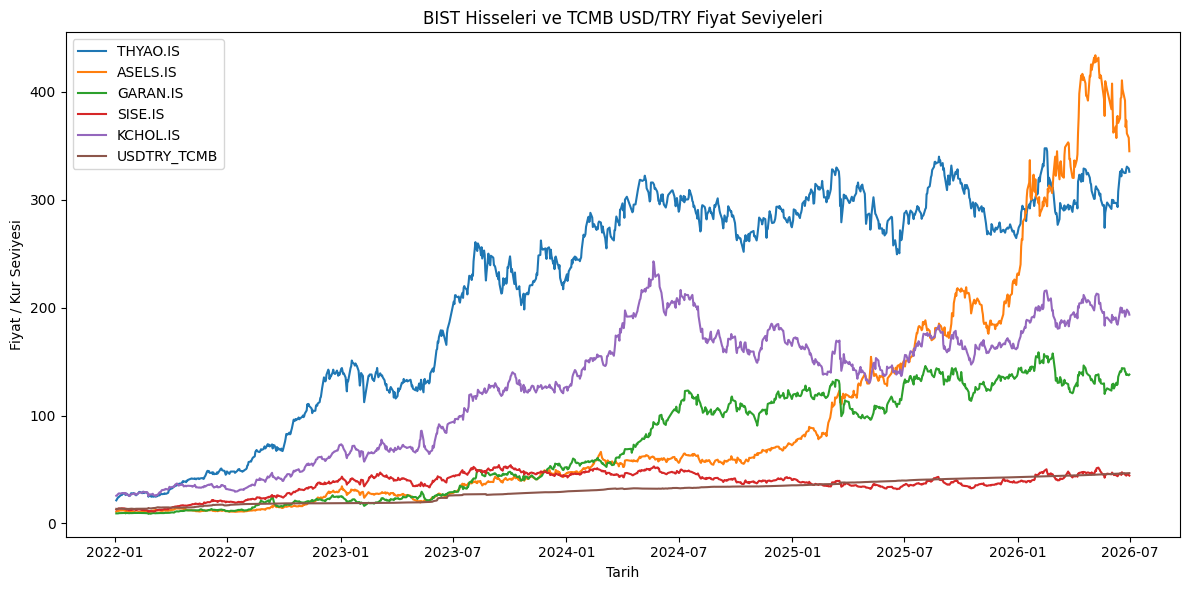

In [20]:
if eda_price_data.empty:
    print("Fiyat seviyesi verisi bulunamadığı için çizgi grafik oluşturulamadı.")
else:
    plot_price_data = eda_price_data[["date", "THYAO.IS", "ASELS.IS", "GARAN.IS", "SISE.IS", "KCHOL.IS", "USDTRY_TCMB"]].copy()
    plot_price_data = plot_price_data.sort_values("date")

    plt.figure(figsize=(12, 6))
    for column in ["THYAO.IS", "ASELS.IS", "GARAN.IS", "SISE.IS", "KCHOL.IS", "USDTRY_TCMB"]:
        plt.plot(plot_price_data["date"], plot_price_data[column], label=column)

    plt.title("BIST Hisseleri ve TCMB USD/TRY Fiyat Seviyeleri")
    plt.xlabel("Tarih")
    plt.ylabel("Fiyat / Kur Seviyesi")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Histogram: THYAO Günlük Getiri Dağılımı

Bu histogram, THYAO hissesinin günlük getiri dağılımını gösterir. Dağılım yapısı, getirilerin hangi aralıklarda yoğunlaştığını anlamaya yardımcı olur.

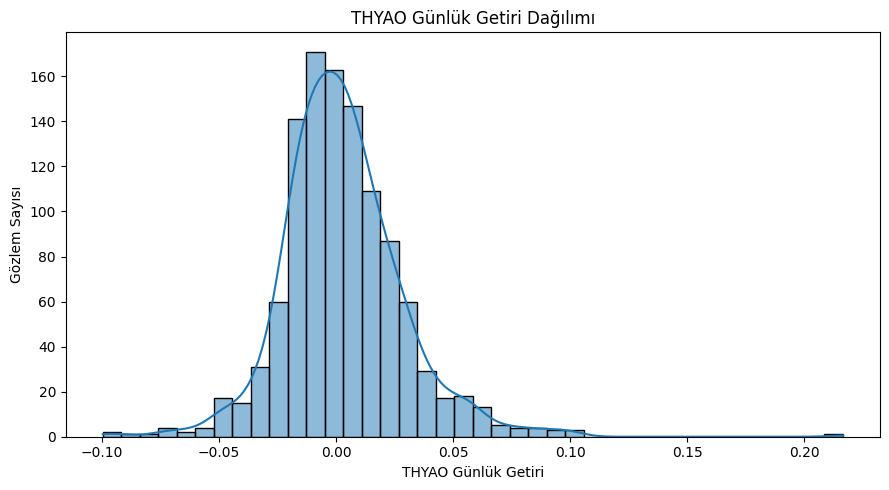

In [21]:
if eda_return_data.empty:
    print("Günlük getiri verisi bulunamadığı için histogram oluşturulamadı.")
else:
    plt.figure(figsize=(9, 5))
    sns.histplot(eda_return_data["THYAO_Return"], bins=40, kde=True)
    plt.title("THYAO Günlük Getiri Dağılımı")
    plt.xlabel("THYAO Günlük Getiri")
    plt.ylabel("Gözlem Sayısı")
    plt.tight_layout()
    plt.show()

### Boxplot: Günlük Getiri Dağılımları

Bu boxplot, seçilen BIST hisseleri ve USD/TRY kuru için günlük getiri dağılımlarını aynı grafikte karşılaştırır.

Aykırı değerler finansal verilerde beklenebilir; bu projede bu değerler silinmemiş, yalnızca incelenmiştir.

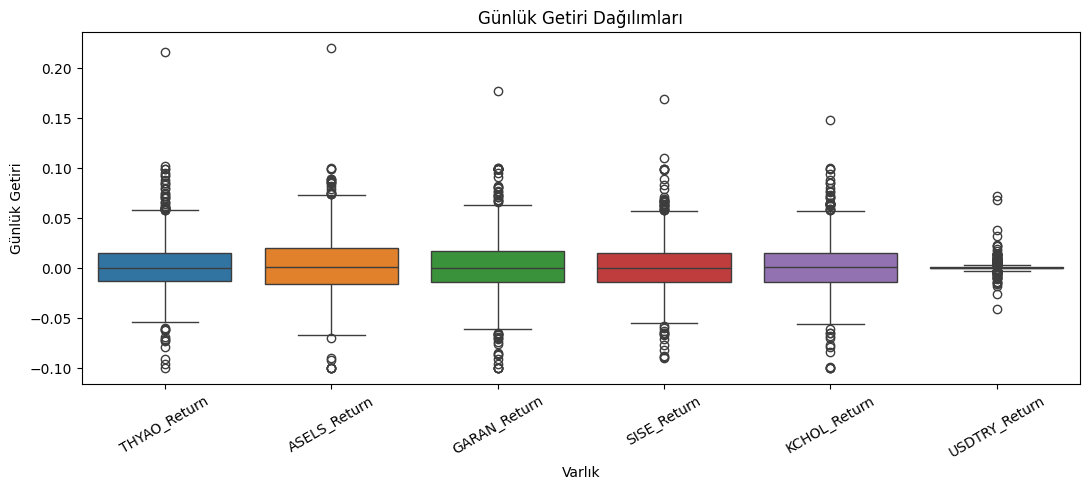

In [22]:
if eda_return_data.empty:
    print("Günlük getiri verisi bulunamadığı için boxplot oluşturulamadı.")
else:
    plt.figure(figsize=(11, 5))
    sns.boxplot(data=eda_return_data[return_columns])
    plt.title("Günlük Getiri Dağılımları")
    plt.xlabel("Varlık")
    plt.ylabel("Günlük Getiri")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Scatter Plot: USDTRY ve THYAO Günlük Getirileri

Bu saçılım grafiği, USD/TRY günlük getirisi ile THYAO günlük getirisi arasındaki ilişkiyi görsel olarak incelemek için kullanılır.

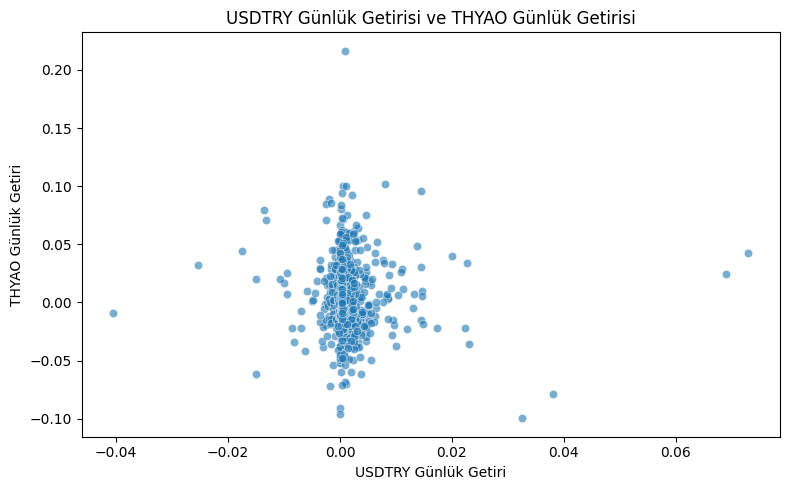

In [23]:
if eda_return_data.empty:
    print("Günlük getiri verisi bulunamadığı için scatter plot oluşturulamadı.")
else:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=eda_return_data, x="USDTRY_Return", y="THYAO_Return", alpha=0.6)
    plt.title("USDTRY Günlük Getirisi ve THYAO Günlük Getirisi")
    plt.xlabel("USDTRY Günlük Getiri")
    plt.ylabel("THYAO Günlük Getiri")
    plt.tight_layout()
    plt.show()

### Korelasyon Isı Haritası

Korelasyon, varlıkların birlikte hareket edip etmediğini anlamak için kullanılır.

Bu ısı haritası günlük getiri değişkenleri arasındaki doğrusal ilişki düzeylerini özetler.

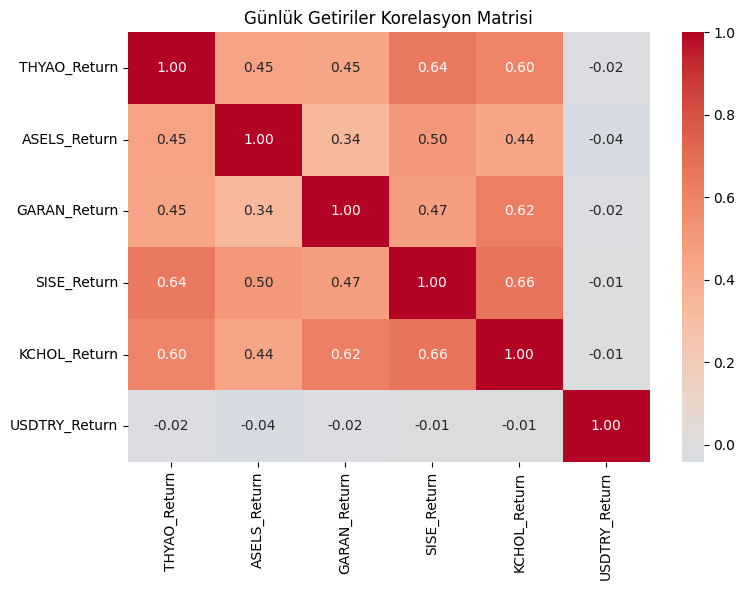

In [24]:
if eda_return_data.empty:
    print("Günlük getiri verisi bulunamadığı için korelasyon ısı haritası oluşturulamadı.")
else:
    correlation_matrix = eda_return_data[return_columns].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Günlük Getiriler Korelasyon Matrisi")
    plt.tight_layout()
    plt.show()

### Bar Chart: Günlük Volatilite Karşılaştırması

Bu sütun grafik, risk-getiri tablosundaki günlük volatilite değerlerini karşılaştırır.

Volatilite burada günlük getirilerin standart sapması olarak hesaplanmıştır.

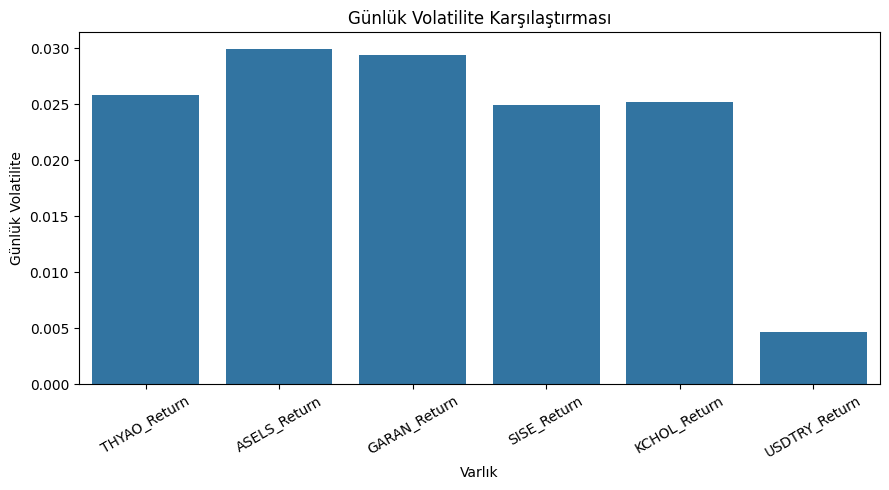

In [25]:
if risk_return_table.empty:
    print("Risk-getiri tablosu boş olduğu için volatilite grafiği oluşturulamadı.")
else:
    plt.figure(figsize=(9, 5))
    sns.barplot(data=risk_return_table, x="Varlık", y="Gunluk_Volatilite")
    plt.title("Günlük Volatilite Karşılaştırması")
    plt.xlabel("Varlık")
    plt.ylabel("Günlük Volatilite")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### EDA Notu

Bu bölümde günlük getiri verisinin temel yapısı, özet istatistikleri, risk-getiri tablosu, aykırı değer sayımları ve temel grafikler oluşturulmuştur.

Bu çıktılar araştırma sorularının yanıtlanmasında ve modelleme sonuçlarının dikkatli yorumlanmasında temel bağlam sağlar.

## 9. Araştırma Soruları ve Yanıtları

Bu bölümde araştırma soruları, önceki EDA çıktıları kullanılarak yanıtlanır.

Yanıtlar betimsel istatistikler, histogram, boxplot, risk-getiri tablosu, scatter plot, korelasyon ısı haritası ve volatilite karşılaştırması gibi mevcut analizlere dayanmaktadır.

Bu yorumlar nedensellik iddiası taşımaz. Finansal getiriler gürültülü olabilir ve bu çalışma yatırım tavsiyesi değildir.

### Araştırma Soruları İçin Yardımcı Özetler

Aşağıdaki küçük yardımcı hücre, mevcut EDA çıktılarından bazı özetleri daha kolay okunur hale getirir. Yeni bir model veya yeni bir grafik oluşturmaz.

In [26]:
stock_return_columns = ["THYAO_Return", "ASELS_Return", "GARAN_Return", "SISE_Return", "KCHOL_Return"]

if "risk_return_table" not in globals() or risk_return_table.empty:
    risk_return_table = pd.DataFrame({
        "Varlık": return_columns,
        "Ortalama_Gunluk_Getiri": eda_return_data[return_columns].mean().values,
        "Gunluk_Volatilite": eda_return_data[return_columns].std().values,
        "Minimum_Getiri": eda_return_data[return_columns].min().values,
        "Maksimum_Getiri": eda_return_data[return_columns].max().values,
    })

stock_risk_return_table = risk_return_table[risk_return_table["Varlık"].isin(stock_return_columns)].copy()
highest_volatility_asset = stock_risk_return_table.sort_values("Gunluk_Volatilite", ascending=False).iloc[0]

correlation_matrix = eda_return_data[return_columns].corr()
usdtry_stock_correlations = correlation_matrix.loc[stock_return_columns, "USDTRY_Return"].sort_values()

stock_correlation_matrix = correlation_matrix.loc[stock_return_columns, stock_return_columns]
stock_correlation_pairs = (
    stock_correlation_matrix.where(np.triu(np.ones(stock_correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
strongest_stock_correlation = stock_correlation_pairs.head(1)

print("BIST hisseleri içinde en yüksek günlük volatilite:")
display(highest_volatility_asset.to_frame().T)

print("USDTRY_Return ile BIST hisse getirileri arasındaki korelasyonlar:")
display(usdtry_stock_correlations.to_frame("Korelasyon"))

print("BIST hisseleri arasındaki en güçlü pozitif korelasyon:")
display(strongest_stock_correlation.to_frame("Korelasyon"))

BIST hisseleri içinde en yüksek günlük volatilite:


,Varlık,Ortalama_Gunluk_Getiri,Gunluk_Volatilite,Minimum_Getiri,Maksimum_Getiri
1,ASELS_Return,0.003564,0.029946,-0.1,0.220126


USDTRY_Return ile BIST hisse getirileri arasındaki korelasyonlar:


,Korelasyon
ASELS_Return,-0.041596
THYAO_Return,-0.020711
GARAN_Return,-0.017904
KCHOL_Return,-0.011603
SISE_Return,-0.010464


BIST hisseleri arasındaki en güçlü pozitif korelasyon:


,,Korelasyon
SISE_Return,KCHOL_Return,0.66375


### Araştırma Sorusu 1

**Soru:**  
Seçilen BIST hisselerinin günlük getiri dağılımları nasıldır?

**Kullanılan analiz:**  
Betimsel istatistikler, THYAO histogramı, tüm getiri sütunları için boxplot ve IQR tabanlı aykırı değer kontrolü kullanılmıştır.

**Bulgu:**  
Günlük getiriler genel olarak sıfıra yakın değerler etrafında yoğunlaşmaktadır. Boxplot ve aykırı değer kontrolü, bazı günlerde normal aralığın dışında kalan hareketler olduğunu göstermektedir.

**Yorum:**  
Bu durum finansal piyasa verileri için beklenebilir. Hisse getirileri kısa vadede dalgalı ve gürültülü olabilir; bu nedenle tekil günlük hareketlerden güçlü sonuçlar çıkarmak doğru değildir.

### Araştırma Sorusu 2

**Soru:**  
Hangi hisse daha yüksek risk/volatilite göstermektedir?

**Kullanılan analiz:**  
`risk_return_table` ve günlük volatilite karşılaştırması için oluşturulan bar chart kullanılmıştır. Yardımcı özet hücresi de BIST hisseleri içinde en yüksek volatiliteye sahip varlığı ayrıca göstermektedir.

**Bulgu:**  
Mevcut risk-getiri tablosuna göre seçilen BIST hisseleri arasında en yüksek günlük volatilite `ASELS_Return` değişkeninde görülmektedir.

**Yorum:**  
Daha yüksek volatilite, ilgili hissenin günlük getirilerinin daha geniş aralıkta değiştiğini gösterir. Bu bulgu yatırım önerisi değildir; yalnızca incelenen dönemdeki geçmiş getiri oynaklığını ifade eder.

### Araştırma Sorusu 3

**Soru:**  
TCMB USD/TRY kuru ile BIST hisselerinin günlük getirileri arasında güçlü bir ilişki var mıdır?

**Kullanılan analiz:**  
USDTRY_Return ile THYAO_Return scatter plotu, korelasyon ısı haritası ve yardımcı özet hücresindeki USDTRY-hisse korelasyonları kullanılmıştır.

**Bulgu:**  
Mevcut korelasyon sonuçları, `USDTRY_Return` ile seçilen BIST hisse getirileri arasında güçlü bir doğrusal ilişki olmadığını göstermektedir. Korelasyonlar düşük seviyededir.

**Yorum:**  
Bu sonuç, günlük bazda döviz kuru değişimleri ile hisse getirileri arasında belirgin ve tek başına açıklayıcı bir doğrusal bağ olmadığını düşündürür. Ancak korelasyon nedensellik göstermez; ayrıca finansal getiriler birçok farklı faktörden etkilenebilir.

### Araştırma Sorusu 4

**Soru:**  
Seçilen BIST hisseleri birbirleriyle benzer hareket ediyor mu?

**Kullanılan analiz:**  
Günlük getiri korelasyon ısı haritası ve yardımcı özet hücresindeki BIST hisseleri arası en güçlü pozitif korelasyon kullanılmıştır.

**Bulgu:**  
Korelasyon ısı haritası, seçilen BIST hisseleri arasında genel olarak pozitif ilişkiler olduğunu göstermektedir. Yardımcı özet hücresinde en güçlü pozitif ilişki de ayrıca listelenmiştir.

**Yorum:**  
Pozitif korelasyonlar, hisselerin bazı dönemlerde aynı piyasa koşullarından birlikte etkilenmiş olabileceğini düşündürür. Yine de bu ilişki birebir aynı hareket ettikleri anlamına gelmez; şirket, sektör ve piyasa dinamikleri farklılık gösterebilir.

## 10. Basit Modelleme

Bu bölümde ders gereksinimini karşılamak için basit ve açıklanabilir bir doğrusal regresyon modeli kurulmuştur.

Hedef değişken `THYAO_Return` olarak seçilmiştir. Bu değişken sayısal olduğu için regresyon modeli uygundur.

Özellik değişkenleri diğer seçili BIST hisselerinin günlük getirileri ile `USDTRY_Return` değişkenidir. Modelde `ASELS_Return`, `GARAN_Return`, `SISE_Return`, `KCHOL_Return` ve `USDTRY_Return` kullanılmıştır.

Modelin amacı yatırım tahmini yapmak değildir. Amaç, veri bilimi iş akışındaki temel modelleme adımını sade biçimde göstermektir. Finansal günlük getiriler gürültülü olduğu için yüksek tahmin başarısı beklenmeyebilir. Bu çalışma yatırım tavsiyesi değildir.

### Modelleme Kütüphaneleri

Bu adımda yalnızca basit doğrusal regresyon için gerekli scikit-learn araçları içe aktarılır. Karmaşık model, hiperparametre ayarı veya derin öğrenme kullanılmaz.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Modelleme İçin Günlük Getiri Verisinin Yüklenmesi

Modelleme için günlük getiri veri seti kullanılır. Eğer `return_data` değişkeni bellekte varsa doğrudan o kullanılır; yoksa `data/processed/daily_return_data.csv` dosyasından yüklenir.

Dosya bulunamazsa önceki notebook hücrelerinin çalıştırılması gerektiğini belirten açık bir Türkçe mesaj gösterilir.

In [28]:
daily_return_data_path = PROCESSED_DATA_DIR / "daily_return_data.csv"

if "return_data" in globals() and isinstance(return_data, pd.DataFrame) and not return_data.empty:
    modeling_source = return_data.copy()
    print("Modelleme verisi bellekteki return_data değişkeninden alındı.")
elif daily_return_data_path.exists():
    modeling_source = pd.read_csv(daily_return_data_path)
    print(f"Modelleme verisi dosyadan yüklendi: {daily_return_data_path}")
else:
    print("Günlük getiri veri dosyası bulunamadı.")
    print("Lütfen önce veri yükleme, temizleme ve günlük getiri hesaplama hücrelerini çalıştırın.")
    modeling_source = pd.DataFrame()

print(f"Modelleme kaynak veri boyutu: {modeling_source.shape}")

Modelleme verisi bellekteki return_data değişkeninden alındı.
Modelleme kaynak veri boyutu: (1112, 7)


### Model Veri Setinin Hazırlanması

Bu modelde hedef değişken `THYAO_Return` olarak belirlenmiştir.

Özellik değişkenleri `ASELS_Return`, `GARAN_Return`, `SISE_Return`, `KCHOL_Return` ve `USDTRY_Return` sütunlarından oluşur. Eksik değer varsa modelleme öncesinde düşürülür.

In [29]:
target_column = "THYAO_Return"
feature_columns = ["ASELS_Return", "GARAN_Return", "SISE_Return", "KCHOL_Return", "USDTRY_Return"]
model_columns = [target_column] + feature_columns

if modeling_source.empty:
    model_data = pd.DataFrame(columns=model_columns)
    print("Modelleme kaynak verisi boş olduğu için model veri seti oluşturulamadı.")
else:
    missing_model_columns = [column for column in model_columns if column not in modeling_source.columns]
    if missing_model_columns:
        raise ValueError(f"Modelleme verisinde beklenen sütunlar eksik: {missing_model_columns}")

    model_data = modeling_source[model_columns].copy()
    for column in model_columns:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

    before_drop = len(model_data)
    model_data = model_data.dropna().reset_index(drop=True)
    dropped_rows = before_drop - len(model_data)
    print(f"Eksik değer nedeniyle çıkarılan satır sayısı: {dropped_rows}")

print(f"Model veri seti boyutu: {model_data.shape}")
display(model_data.head())

Eksik değer nedeniyle çıkarılan satır sayısı: 0
Model veri seti boyutu: (1112, 6)


,THYAO_Return,ASELS_Return,GARAN_Return,SISE_Return,KCHOL_Return,USDTRY_Return
0,0.043956,0.032110,-0.002618,0.028860,0.009914,-0.017494
1,0.048246,0.023111,0.001750,0.010519,0.028141,0.013756
2,0.040167,0.010426,0.002620,0.030534,0.021006,0.019935
3,0.003218,0.008598,0.023519,0.000673,0.021820,0.008610
4,0.070569,0.031543,-0.000851,0.002692,-0.004271,-0.002407


### Eğitim ve Test Ayrımı ile Model Eğitimi

Finansal veriler zaman sıralı olduğu için eğitim-test ayrımında `shuffle=False` kullanılır. Böylece gözlemler rastgele karıştırılmaz ve kronolojik sıra korunur.

Model olarak `LinearRegression` kullanılır. Bu model basit, açıklanabilir ve ders kapsamına uygundur.

In [30]:
if model_data.empty or len(model_data) < 10:
    print("Model eğitimi için yeterli veri bulunamadı.")
    X_train = X_test = pd.DataFrame(columns=feature_columns)
    y_train = y_test = pd.Series(dtype=float)
    y_pred = np.array([])
    linear_model = None
else:
    X = model_data[feature_columns]
    y = model_data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    y_pred = linear_model.predict(X_test)

    print(f"Eğitim veri boyutu: {X_train.shape}")
    print(f"Test veri boyutu: {X_test.shape}")

Eğitim veri boyutu: (889, 5)
Test veri boyutu: (223, 5)


### Model Sonuçları ve Katsayılar

Bu bölümde model performansı MAE, RMSE ve R² metrikleriyle özetlenir.

MAE ortalama mutlak hatayı, RMSE hataların kareli ortalamasının karekökünü, R² ise modelin test verisindeki açıklama gücünü gösterir.

Finansal günlük getiriler gürültülü olduğu için R² değerinin düşük veya negatif çıkması mümkündür. Bu durum, modelin günlük getirileri güvenilir biçimde tahmin ettiğini göstermediği gibi, değişkenler arasında nedensellik olduğu anlamına da gelmez.

In [31]:
if linear_model is None or len(y_pred) == 0:
    model_results = pd.DataFrame(columns=["Metrik", "Değer"])
    coefficient_table = pd.DataFrame(columns=["Özellik", "Katsayı"])
    print("Model sonuçları hesaplanamadı.")
else:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    model_results = pd.DataFrame({
        "Metrik": ["MAE", "RMSE", "R²"],
        "Değer": [mae, rmse, r2],
    })

    coefficient_table = pd.DataFrame({
        "Özellik": feature_columns,
        "Katsayı": linear_model.coef_,
    })

print("Model performans metrikleri:")
display(model_results)

print("Regresyon katsayıları:")
display(coefficient_table)

Model performans metrikleri:


,Metrik,Değer
0,MAE,0.011856
1,RMSE,0.015086
2,R²,0.388224


Regresyon katsayıları:


,Özellik,Katsayı
0,ASELS_Return,0.133401
1,GARAN_Return,0.037476
2,SISE_Return,0.438795
3,KCHOL_Return,0.236278
4,USDTRY_Return,-0.018102


### Gerçek ve Tahmin Edilen THYAO Günlük Getirileri

Bu grafik test dönemindeki gerçek `THYAO_Return` değerleri ile modelin tahmin ettiği değerleri karşılaştırır.

Grafik yalnızca model davranışını görsel olarak incelemek içindir. Modelin güvenilir yatırım tahmini yaptığı şeklinde yorumlanmamalıdır.

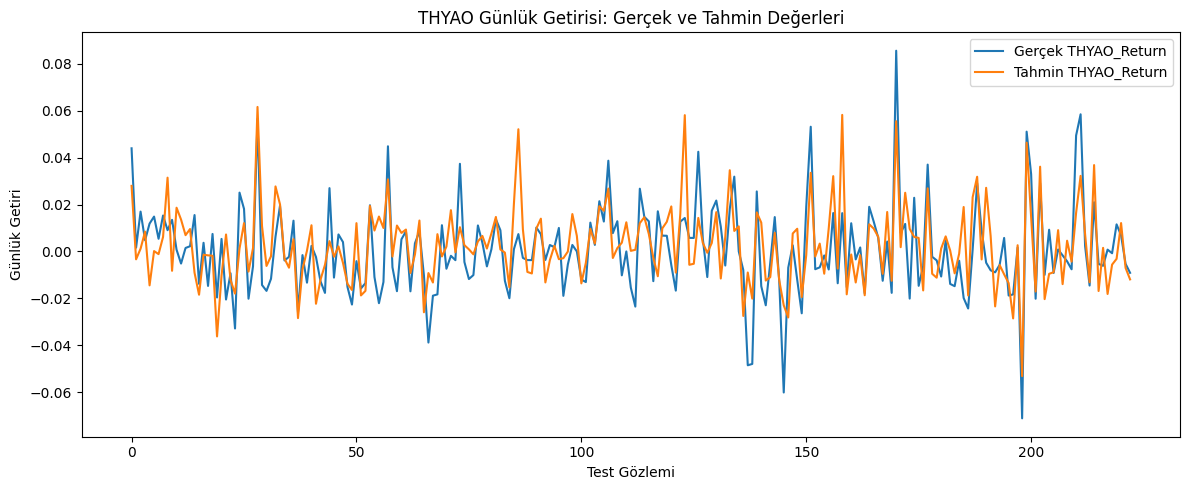

In [32]:
if linear_model is None or len(y_pred) == 0:
    print("Tahmin sonucu olmadığı için gerçek-tahmin grafiği oluşturulamadı.")
else:
    prediction_comparison = pd.DataFrame({
        "Gerçek_THYAO_Return": y_test.values,
        "Tahmin_THYAO_Return": y_pred,
    }).reset_index(drop=True)

    plt.figure(figsize=(12, 5))
    plt.plot(prediction_comparison.index, prediction_comparison["Gerçek_THYAO_Return"], label="Gerçek THYAO_Return")
    plt.plot(prediction_comparison.index, prediction_comparison["Tahmin_THYAO_Return"], label="Tahmin THYAO_Return")
    plt.title("THYAO Günlük Getirisi: Gerçek ve Tahmin Değerleri")
    plt.xlabel("Test Gözlemi")
    plt.ylabel("Günlük Getiri")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Modelleme Notu

Bu model, proje kapsamında temel modelleme adımını göstermek için kurulmuştur. Günlük finansal getiriler kısa vadede yüksek ölçüde değişken ve gürültülü olabilir.

Bu nedenle model sonuçları dikkatli yorumlanmalıdır. Model yatırım kararı vermek için kullanılmamalıdır ve bu çalışma yatırım tavsiyesi değildir.

## 11. Bulguların Yorumlanması

Analiz sonuçları, seçilen BIST hisselerinin günlük getirilerinde dalgalanma ve zaman zaman aykırı hareketler olduğunu göstermektedir.

Risk-getiri tablosu ve volatilite grafiği, seçilen hisselerin risk düzeylerinin birbirinden farklılaştığını göstermiştir.

Korelasyon analizi, bazı BIST hisselerinin birlikte hareket etme eğilimi gösterebildiğini; ancak bu ilişkinin nedensellik anlamına gelmediğini ortaya koymaktadır.

TCMB USD/TRY getirisi ile hisse getirileri arasındaki ilişki düşük düzeyde görünmektedir ve bu sonuç dikkatli yorumlanmalıdır.

Doğrusal regresyon modeli temel bir modelleme örneği sunmuştur; ancak günlük finansal getiriler gürültülü olduğu için model sonuçları abartılmadan değerlendirilmelidir.

## 12. Sınırlamalar

Bu projede yalnızca beş seçili BIST hissesi incelenmiştir: `THYAO.IS`, `ASELS.IS`, `GARAN.IS`, `SISE.IS` ve `KCHOL.IS`.

Analiz dönemi `2022-01-01` ile `2026-06-30` arasındaki verilerle sınırlıdır.

Makro-finansal değişken olarak yalnızca TCMB USD/TRY döviz kuru kullanılmıştır.

Şirket haberleri, faiz oranları, enflasyon, bilanço verileri, sektör bazlı gelişmeler ve küresel piyasa göstergeleri analize dahil edilmemiştir.

Günlük finansal getiriler gürültülü ve tahmin edilmesi zor olabilir. Korelasyon sonuçları nedensellik anlamına gelmez.

Bu proje eğitim amaçlıdır ve yatırım tavsiyesi değildir.

## 13. Sonuç

Bu notebook, gerçek/gerçekçi finansal veriler üzerinde temel veri bilimi iş akışını uygulamıştır.

Çalışmada veri yükleme, veri temizleme, veri birleştirme, günlük getiri hesaplama, keşifsel veri analizi, görselleştirme, araştırma sorularının yanıtlanması ve basit doğrusal regresyon modelleme adımları tamamlanmıştır.

Araştırma soruları EDA çıktıları ve temel modelleme sonuçlarıyla ilişkilendirilerek yorumlanmıştır.

Sonuçlar, finansal veri analizinde günlük getirilerin gürültülü yapısı nedeniyle dikkatli ve sınırlılıkların farkında olarak yorum yapılması gerektiğini göstermektedir.

Bu çalışma, ders kapsamında gerçek/gerçekçi bir veri seti üzerinde temel veri bilimi iş akışını uygulama amacını karşılamaktadır.